# Feature Evaluation: NASDAQ-100 Microstructure

Univariate screening of the financial and model-based feature sets against the
forward midprice return declared at `setup.yaml::labels.primary`. Produces the
per-feature triage decisions the modeling chapters read.

**Book reference**: §7.3 (univariate feature-label evaluation) and §7.4 (search
accounting and multiple testing). §8.6 is the secondary reference for search control.

**Learning Objectives**:
- Seal an intraday panel on the label endpoint before any statistic is computed
- Evaluate the candidate set jointly using HAC-adjusted IC and BH-FDR correction
- Screen for coverage and staleness issues (critical for intraday data)
- Assess quantile monotonicity and cross-feature redundancy
- Triage features into PROCEED / REVISE / STOP categories

**What it reads**:
- `features/financial.parquet`, `features/model_based.parquet` (the candidate set)
- `labels/<primary>.parquet` plus the declared forward-return variants, for the
  horizon profile
- `config/setup.yaml` (holdout boundary, label horizons, fold count)

**What it writes**:
- `evaluation/triage_ledger.parquet` — one row per feature with triage decision
- `evaluation/ic_timeseries.parquet` — long-format IC time series, plotted below by
  the IC-through-time figure

**Cross-References**:
- **Upstream**: [`03_financial_features`](03_financial_features.ipynb),
  [`04_model_based_features`](04_model_based_features.ipynb),
  [`02_labels`](02_labels.ipynb)
- **Downstream**: `20_strategy_synthesis/02_feature_evaluation.py`, which reads the
  triage ledger of every case study and tabulates them together. Nothing else reads
  either artifact today: the model notebooks train on the full feature matrix and
  let regularization and importance do the selecting, so a STOP here is a recorded
  judgment about a feature, not a filter applied on the reader's behalf.

In [1]:
"""Feature Evaluation - NASDAQ-100 Microstructure

Univariate screening of the financial and model-based feature sets against the
declared forward return labels. Produces per-feature triage decisions.
"""

import warnings

import yaml

warnings.filterwarnings("ignore")

import re
from datetime import datetime

import numpy as np
import plotly.graph_objects as go
import polars as pl
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats, compute_ic_uncertainty
from plotly.subplots import make_subplots
from scipy.stats import spearmanr
from scipy.stats import t as student_t

from utils.cv_splits import generate_cv_splits
from utils.data_quality import validate_modeling_inputs
from utils.paths import get_case_study_dir
from utils.style import COLORS, GRAY_FILLS


def _normalize_symbol_column(df: pl.DataFrame) -> pl.DataFrame:
    if "symbol" in df.columns:
        return df
    msg = f"Expected symbol-like column in frame, found columns={df.columns}"
    raise KeyError(msg)

In [2]:
# Production defaults — Papermill overrides for testing
# MAX_SYMBOLS: 0 = all symbols; set to 20 for fast CI
MAX_SYMBOLS = 0

In [3]:
CASE_STUDY_ID = "nasdaq100_microstructure"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
EVAL_DIR = CASE_DIR / "evaluation"
EVAL_WRITE_DIR = EVAL_DIR.resolve(strict=False) if EVAL_DIR.is_symlink() else EVAL_DIR
EVAL_WRITE_DIR.mkdir(parents=True, exist_ok=True)

JOIN_COLS = ["timestamp", "symbol"]
DATE_COL = "timestamp"

## Configuration

Two kinds of constant, kept apart deliberately. The label, its horizon and the
holdout boundary describe the case study and are read from `config/setup.yaml`, so
a change to the declared setup moves this notebook with it rather than past it.
The screening thresholds below them are this notebook's own judgment about what
counts as enough coverage or enough stability; they belong to the screen rather
than to the case study, and they are named here so the prose can refer to them
instead of retyping their values.

In [4]:
def horizon_minutes(spec: str) -> int:
    """Minutes in a `setup.yaml` label buffer such as `15min`."""
    match = re.fullmatch(r"(\d+)min", str(spec).strip())
    if match is None:
        msg = f"Label buffer {spec!r} is not expressed in minutes"
        raise ValueError(msg)
    return int(match.group(1))


with open(CASE_DIR / "config" / "setup.yaml") as f:
    setup = yaml.safe_load(f)
cv_config = setup["evaluation"]

# The panel is a one-minute grid, so a buffer in minutes is a horizon in bars.
PRIMARY_LABEL = setup["labels"]["primary"]
LABEL_HORIZON = horizon_minutes(setup["labels"]["buffer"])
# The continuous forward-return labels this case study ships, primary first. The
# classification variant is excluded: a rank IC against a binary label answers a
# different question and does not belong on the horizon profile.
LABEL_HORIZONS = {
    name: horizon_minutes(spec)
    for name, spec in [
        (PRIMARY_LABEL, setup["labels"]["buffer"]),
        *sorted(setup["labels"]["variant_buffers"].items()),
    ]
    if name.startswith("fwd_ret")
}
HOLDOUT_START = datetime.fromisoformat(str(cv_config["holdout_start"]))
N_FOLDS = int(cv_config["n_splits"])

# One IC observation per label horizon: at a 15-bar horizon on a one-minute grid,
# consecutive cross-sectional ICs would otherwise overlap in 14 of their 15 bars.
IC_SAMPLE_STEP = LABEL_HORIZON
# Newey-West bandwidth covering one full NYSE regular session of IC observations
# (the calendar is declared at `setup.yaml::evaluation.calendar`). It is derived
# from the sampling step rather than typed so the two cannot drift apart.
SESSION_MINUTES = 390
HAC_MAXLAGS = SESSION_MINUTES // IC_SAMPLE_STEP

# Screening thresholds. Intraday cross-sections are wide and the signal-to-noise
# ratio is low, so the IC bar is deliberately near zero.
COVERAGE_MIN = 0.70
STALENESS_MAX = 0.50
FDR_ALPHA = 0.05
SIGN_CONSISTENCY_MIN = 0.60
MONOTONICITY_MIN = 0.80
REDUNDANCY_CUT = 0.70
IC_THRESHOLD = 0.003
MIN_PERIODS_DEFAULT = 10  # 101-114 symbols → 10 is conservative

## 0. Panel and the Holdout Seal

Load the financial features, the model-based features and the primary label, and
join them on `(timestamp, symbol)`.

**The seal.** A row's label endpoint is its timestamp plus `LABEL_HORIZON` minutes,
which is the bar the forward return settles on. A row is eligible only when that
endpoint falls strictly before `HOLDOUT_START`. Sealing on the signal timestamp
instead would admit the last `LABEL_HORIZON` bars of development, whose labels are
realized inside the evaluation window. The seal is applied to the lazy scans, so no
statistic in this notebook — not the coverage screen, not the quantile profile, not
the redundancy correlation — ever sees a holdout row.

In [5]:
# Identify feature columns before loading (peek at schema)
features_path = CASE_DIR / "features" / "financial.parquet"
temporal_path = CASE_DIR / "features" / "model_based.parquet"
label_path = CASE_DIR / "labels" / f"{PRIMARY_LABEL}.parquet"

# The walk-forward folds. `generate_cv_splits` derives them from the label frame, the
# same call `04_model_based_features` makes when it fits the temporal features, so a
# fold id denotes the same window on both sides of the join below.
splits = generate_cv_splits(
    pl.scan_parquet(label_path).select(DATE_COL).unique().sort(DATE_COL).collect(),
    case_study_id=CASE_STUDY_ID,
    label_buffer=setup["labels"]["buffer"],
)

financial_cols = [
    c for c in pl.read_parquet_schema(features_path) if c not in ("timestamp", "symbol")
]
temporal_cols = [
    c for c in pl.read_parquet_schema(temporal_path) if c not in ("timestamp", "symbol", "fold")
]
all_feature_cols = financial_cols + temporal_cols

# Determine symbol filter (if MAX_SYMBOLS > 0, pick top symbols by count)
symbol_filter = None
if MAX_SYMBOLS > 0:
    counts = (
        _normalize_symbol_column(pl.scan_parquet(features_path).collect()).group_by("symbol").len()
    )
    top_syms = counts.sort("len", descending=True).head(MAX_SYMBOLS)["symbol"].to_list()
    symbol_filter = pl.col("symbol").is_in(top_syms)

# Load with optional filter — avoids materializing the full panel in test mode
features = pl.scan_parquet(features_path)
temporal = pl.scan_parquet(temporal_path)
label_df = pl.scan_parquet(label_path)

if symbol_filter is not None:
    features = features.filter(symbol_filter)
    temporal = temporal.filter(symbol_filter)
    label_df = label_df.filter(symbol_filter)

# The seal, pushed into the scans so holdout rows are never materialized at all.
label_endpoint = pl.col(DATE_COL) + pl.duration(minutes=LABEL_HORIZON)
holdout_seal = label_endpoint < HOLDOUT_START
features = features.filter(holdout_seal)
temporal = temporal.filter(holdout_seal)
label_df = label_df.filter(holdout_seal)

features = _normalize_symbol_column(features.collect())
temporal = _normalize_symbol_column(temporal.collect())
# Resolve the fold dimension. `model_based.parquet` carries one fitted value per
# fold, so `fold` is part of its key while the panel needs one temporal row per
# `(timestamp, symbol)`. A fitted value is out of sample only inside its own fold's
# validation window, so keeping it there and dropping the holdout fold selects
# exactly one value per bar and symbol.
val_windows = {int(s["fold"]): (s["val_start"], s["val_end"]) for s in splits}
_ts_dtype = temporal.schema[DATE_COL]
temporal = (
    temporal.filter(pl.col("fold").is_in(list(val_windows)))
    .filter(
        pl.col("fold")
        .replace_strict({f: s for f, (s, _) in val_windows.items()}, default=None)
        .cast(_ts_dtype)
        <= pl.col(DATE_COL)
    )
    .filter(
        pl.col(DATE_COL)
        <= pl.col("fold")
        .replace_strict({f: e for f, (_, e) in val_windows.items()}, default=None)
        .cast(_ts_dtype)
    )
    .drop("fold")
)
assert temporal.select(JOIN_COLS).is_duplicated().sum() == 0, (
    "validation windows overlap; a fitted feature would take two values on one bar"
)
label_df = _normalize_symbol_column(label_df.collect())

# Auto-detect label column
label_col = [c for c in label_df.columns if c not in ("timestamp", "symbol")][0]

## Artifact Quality Gate

Verify upstream artifacts are free of critical defects before evaluation. This is
the artifact gate — infinities, negative prices, extreme returns — and it is a
different question from the per-feature coverage and staleness screens below.

In [6]:
validate_modeling_inputs(
    features_df=features,
    label_df=label_df,
    feature_cols=financial_cols + temporal_cols,
    label_col=label_col,
    join_cols=JOIN_COLS,
    asset_col="symbol",
    max_abs_return=1.0,  # 15-minute returns (max observed ~0.60, circuit breakers)
    fail_on_critical=True,
)

Data Quality Gate: 0 CRITICAL, 1 WARNING
  [!] WARNING: 1 features have values |x| > 1e+06: dollar_vol(3873346)


{'issues': ['WARNING: 1 features have values |x| > 1e+06: dollar_vol(3873346)'],
 'n_critical': 0,
 'n_warning': 1}

In [7]:
# Build unified eval panel, then free source DataFrames
eval_panel = features.join(temporal, on=JOIN_COLS, how="left")
eval_panel = eval_panel.join(label_df, on=JOIN_COLS, how="inner")
del features, temporal, label_df

# The seal, proven on the assembled panel rather than assumed from the scan plan.
# A duplicate key would double-count a decision time in every cross-section below,
# so it raises here rather than surfacing as a quietly wrong IC.
assert eval_panel.select(label_endpoint.max()).item() < HOLDOUT_START
assert eval_panel.select(pl.struct(JOIN_COLS).n_unique()).item() == len(eval_panel)

# Screen every candidate on the frame where it can exist. A Chapter 9 feature is out
# of sample only inside the validation window of the fold that fitted it, so over the
# whole pre-holdout span its coverage is the share of that span the windows reach and
# the correctness gate below reads a property of the design as a broken feature. The
# panel is the union of the windows, which puts the Chapter 8 features on the same
# bars as the Chapter 9 ones and makes the two ICs comparable.
IN_VALIDATION = pl.any_horizontal(
    [
        (pl.col(DATE_COL) >= pl.lit(start).cast(_ts_dtype))
        & (pl.col(DATE_COL) <= pl.lit(end).cast(_ts_dtype))
        for start, end in val_windows.values()
    ]
)
n_before_windows = len(eval_panel)
eval_panel = eval_panel.filter(IN_VALIDATION)
print(
    f"Narrowed to the union of the validation windows: {n_before_windows:,} -> "
    f"{len(eval_panel):,} rows"
)

n_rows = len(eval_panel)
n_symbols = eval_panel["symbol"].n_unique()
n_dates = eval_panel[DATE_COL].n_unique()
MIN_PERIODS = min(MIN_PERIODS_DEFAULT, n_symbols)
print(f"Eval panel: {n_rows:,} rows, {n_symbols} symbols, {n_dates:,} timestamps")
print(
    f"Sealed span: {eval_panel[DATE_COL].min()} to {eval_panel[DATE_COL].max()}"
    f" (label endpoints strictly before {HOLDOUT_START.date()})"
)
print(
    f"Features: {len(financial_cols)} financial + {len(temporal_cols)} temporal"
    f" = {len(all_feature_cols)} total"
)
print(f"Label: {label_col}")

Narrowed to the union of the validation windows: 11,986,314 -> 8,027,555 rows
Eval panel: 8,027,555 rows, 111 symbols, 79,112 timestamps
Sealed span: 2020-06-30 10:31:00 to 2021-06-30 15:44:00 (label endpoints strictly before 2021-07-01)
Features: 66 financial + 22 temporal = 88 total
Label: fwd_ret_15m


## 1. Correctness Screens

Check coverage (fraction non-null) and staleness (fraction unchanged from prior
bar) for every feature before evaluating predictive power. Intraday data is
especially prone to stale quotes — a quote-based feature that never updates
signals stale NBBO.

These are the two of book §7.3's four correctness questions this notebook owns.
Timing and lag consistency, and mask alignment, are settled upstream by
`03_financial_features` and `04_model_based_features`, which declare each family's
lag against `setup.yaml::features.families` and audit it there.

**Gate**: a feature clears when its coverage reaches `COVERAGE_MIN` and its
staleness stays at or below `STALENESS_MAX`. Both bounds are declared in the
configuration cell and printed with the counts below.

In [8]:
# Coverage: fraction non-null per feature
coverage = {}
for feat in all_feature_cols:
    n_valid = eval_panel[feat].drop_nulls().len()
    coverage[feat] = n_valid / n_rows if n_rows > 0 else 0.0

# Staleness: fraction of rows where feature value is unchanged from prior bar
# (especially important for intraday microstructure data)
# Vectorized: sort once, compute all shift comparisons in one with_columns
sorted_panel = eval_panel.sort(JOIN_COLS)
stale_exprs = [
    (pl.col(f) == pl.col(f).shift(1).over("symbol")).alias(f"_stale_{f}") for f in all_feature_cols
]
stale_df = sorted_panel.select(stale_exprs)
staleness = {
    f: float(stale_df[f"_stale_{f}"].sum()) / max(n_rows - n_symbols, 1) for f in all_feature_cols
}
del stale_df, sorted_panel

In [9]:
# Apply correctness gate
correctness = {}
for feat in all_feature_cols:
    cov_ok = coverage[feat] >= COVERAGE_MIN
    stale_ok = staleness[feat] <= STALENESS_MAX
    correctness[feat] = cov_ok and stale_ok

n_pass = sum(correctness.values())
n_fail = len(correctness) - n_pass
print(f"Gate: coverage >= {COVERAGE_MIN:.0%}, staleness <= {STALENESS_MAX:.0%}")
print(f"Correctness gate: {n_pass} PASS, {n_fail} FAIL")

if n_fail > 0:
    fail_df = pl.DataFrame(
        {
            "feature": [f for f, ok in correctness.items() if not ok],
            "coverage": [coverage[f] for f, ok in correctness.items() if not ok],
            "staleness": [staleness[f] for f, ok in correctness.items() if not ok],
        }
    )
    print(fail_df)

Gate: coverage >= 70%, staleness <= 50%
Correctness gate: 83 PASS, 5 FAIL
shape: (5, 3)
┌─────────────────────┬──────────┬───────────┐
│ feature             ┆ coverage ┆ staleness │
│ ---                 ┆ ---      ┆ ---       │
│ str                 ┆ f64      ┆ f64       │
╞═════════════════════╪══════════╪═══════════╡
│ cross_locked_share  ┆ 1.0      ┆ 0.719133  │
│ is_first_30m        ┆ 1.0      ┆ 1.0       │
│ is_last_30m         ┆ 1.0      ┆ 0.993618  │
│ vol_dominant_period ┆ 0.999933 ┆ 0.836824  │
│ rv_dominant_period  ┆ 0.999836 ┆ 0.834306  │
└─────────────────────┴──────────┴───────────┘


## 2. Univariate Association (IC + HAC)

Compute the Information Coefficient (IC) — the cross-sectional Spearman rank
correlation between each feature and the primary label — at every sampled
timestamp, then average. Newey-West standard errors over `HAC_MAXLAGS` lags correct
for serial correlation in the resulting IC series; the series is sorted on the time
axis before it reaches the estimator, because the lag structure is otherwise
computed over an arbitrary permutation.

**Sampling**: one timestamp per `IC_SAMPLE_STEP` bars, which is one per label
horizon. Consecutive cross-sections on the full one-minute grid share all but one
bar of their forward window, so their ICs are near-duplicates; at horizon spacing
they are approximately non-overlapping. This is the one place in the pipeline where
the IC is not computed at every decision time, and the reason is the overlap.

**Caveat on the sampling**: `gather_every` strides the global sorted list of unique
timestamps, so the stride does not restart at each session open. A retained
timestamp can therefore sit at a different offset within one session than within
the next.

In [10]:
evaluable_features = [f for f in all_feature_cols if correctness[f]]

# One timestamp per label horizon, to approximate independence
all_timestamps = eval_panel[DATE_COL].unique().sort()
sample_ts = all_timestamps.gather_every(IC_SAMPLE_STEP)
eval_sampled = eval_panel.filter(pl.col(DATE_COL).is_in(sample_ts))
print(
    f"Evaluating {len(evaluable_features)} features on {len(sample_ts):,}"
    f" sampled timestamps ({len(eval_sampled):,} rows)"
)

Evaluating 83 features on 5,275 sampled timestamps (535,258 rows)


In [11]:
# Detect date-level features (zero cross-sectional variance)
cs_std_df = eval_sampled.group_by(DATE_COL).agg(
    [pl.col(f).std().alias(f) for f in evaluable_features]
)
date_level_features = set()
for feat in evaluable_features:
    mean_std = cs_std_df[feat].drop_nulls().mean()
    if mean_std is not None and mean_std < 1e-10:
        date_level_features.add(feat)

if date_level_features:
    print(f"Date-level features (zero CS variance): {sorted(date_level_features)}")

Date-level features (zero CS variance): ['time_since_open', 'time_to_close']


In [12]:
# Vectorized IC: Polars group_by + pl.corr computes all features × timestamps at once
cs_features = [f for f in evaluable_features if f not in date_level_features]

# Filter timestamps with enough observations
ts_counts = eval_sampled.group_by(DATE_COL).len().filter(pl.col("len") >= MIN_PERIODS)
eval_sub = eval_sampled.filter(pl.col(DATE_COL).is_in(ts_counts[DATE_COL]))

# Compute cross-sectional Spearman IC for all features at every timestamp
ic_wide = (
    eval_sub.group_by(DATE_COL)
    .agg(
        [pl.corr(f, label_col, method="spearman").alias(f) for f in cs_features]
        + [pl.len().alias("n_obs")]
    )
    .sort(DATE_COL)
)

print(f"IC computed: {len(cs_features)} features × {len(ic_wide):,} timestamps")

IC computed: 81 features × 5,275 timestamps


In [13]:
# Unpivot to per-feature IC series and compute HAC stats.
# `pl.corr` returns NaN, not null, for a cross-section with no variance in the
# feature, and a NaN is not an observation of the IC: left in, it poisons every
# mean, rolling window and interval computed downstream. `is_finite` drops both
# spellings of "no value here" in one filter.
ic_results = {}
ic_timeseries = {}
for feat in cs_features:
    ic_df = ic_wide.select([DATE_COL, pl.col(feat).alias("ic"), "n_obs"]).filter(
        pl.col("ic").is_finite()
    )
    if len(ic_df) < 20:
        continue
    hac_stats = compute_ic_hac_stats(ic_df, ic_col="ic", maxlags=HAC_MAXLAGS)
    ic_results[feat] = hac_stats
    ic_timeseries[feat] = ic_df

print(f"HAC stats for {len(ic_results)} cross-sectional features")
print(f"Skipped {len(date_level_features)} date-level features")

HAC stats for 81 cross-sectional features
Skipped 2 date-level features


### The IC Series Itself

The mean IC is a scalar summary of a series, and two of the patterns that decide
whether a feature is usable are visible only in the series: an association carried
by one episode, and an association that changes sign. The left panel draws the
per-decision-time IC of the leading feature under a rolling mean; the right panel
puts three ways of bounding the mean on one axis for the leading features — the
naive interval that assumes independent observations, the Newey-West interval that
does not, and the block-bootstrap bounds that assume neither a variance formula nor
a distribution.

The series drawn here is the one the notebook later writes to
`evaluation/ic_timeseries.parquet`, so the artifact is not written for nobody:
the figure is its first reader, in memory, and the parquet is the same values on
disk for anyone who wants them at a different grain.

In [14]:
# One trading week of IC observations, at one observation per label horizon.
IC_ROLLING_WINDOW = 5 * SESSION_MINUTES // IC_SAMPLE_STEP
BOOT_BOUNDS = ("ci_boot_lower", "ci_boot_upper")

leaders = sorted(ic_results, key=lambda name: abs(ic_results[name]["mean_ic"]), reverse=True)[:8]
# `compute_ic_uncertainty` sets its lag to `horizon - 1` and its bootstrap block to
# `horizon`, both counted in observations of the series it is handed. Passing one
# more than `HAC_MAXLAGS` gives the bands the same session-wide bandwidth the HAC
# table above uses, so the two are the same correction read two ways.
ic_uncertainty = {
    feature: compute_ic_uncertainty(ic_timeseries[feature], horizon=HAC_MAXLAGS + 1, ic_col="ic")
    for feature in leaders
}
leader = leaders[0] if leaders else None
print(f"Leading feature by absolute mean IC: {leader}")

Leading feature by absolute mean IC: sig2_trd_ret


In [15]:
def interval_arms(features: list[str], lower: str, upper: str) -> dict:
    """Asymmetric Plotly error bars from a pair of interval bounds."""
    return {
        "type": "data",
        "symmetric": False,
        "array": [
            ic_uncertainty[name][upper] - ic_uncertainty[name]["mean_ic"] for name in features
        ],
        "arrayminus": [
            ic_uncertainty[name]["mean_ic"] - ic_uncertainty[name][lower] for name in features
        ],
    }

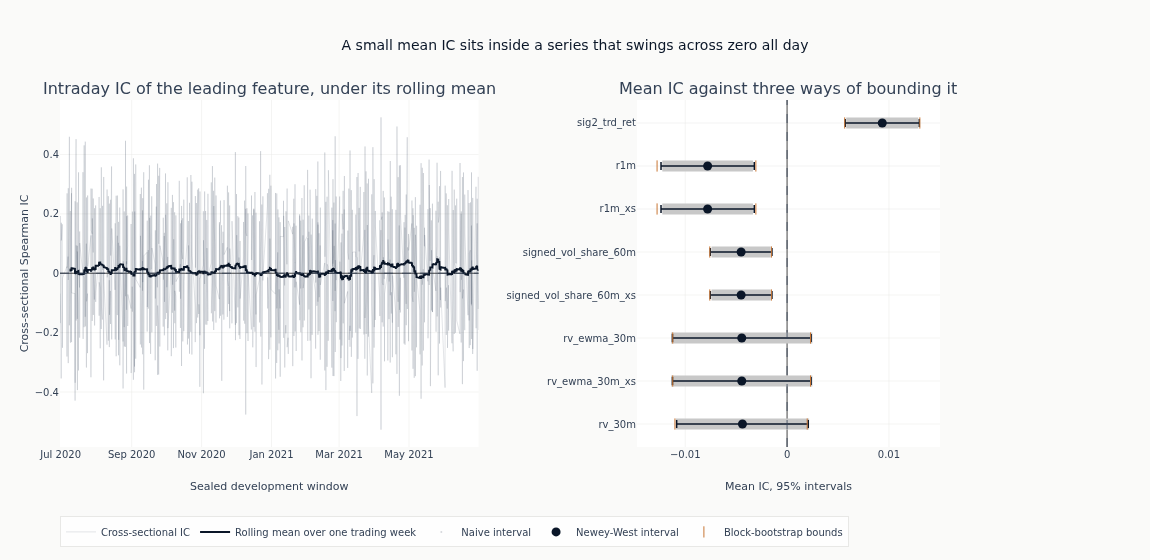

In [16]:
if leader:
    leader_series = ic_timeseries[leader].with_columns(
        pl.col("ic").rolling_mean(IC_ROLLING_WINDOW).alias("rolling")
    )
    interval_features = list(reversed(leaders))
    interval_means = [ic_uncertainty[name]["mean_ic"] for name in interval_features]
    fig = make_subplots(
        rows=1,
        cols=2,
        column_widths=[0.58, 0.42],
        subplot_titles=(
            "Intraday IC of the leading feature, under its rolling mean",
            "Mean IC against three ways of bounding it",
        ),
        horizontal_spacing=0.18,
    )
    _ = fig.add_trace(
        go.Scatter(
            x=leader_series[DATE_COL],
            y=leader_series["ic"],
            mode="lines",
            line={"color": COLORS["neutral"], "width": 0.4},
            opacity=0.35,
            name="Cross-sectional IC",
        ),
        row=1,
        col=1,
    )
    _ = fig.add_trace(
        go.Scatter(
            x=leader_series[DATE_COL],
            y=leader_series["rolling"],
            mode="lines",
            line={"color": COLORS["blue"], "width": 2},
            name="Rolling mean over one trading week",
        ),
        row=1,
        col=1,
    )
    _ = fig.add_hline(
        y=0, line={"color": COLORS["neutral"], "width": 0.8, "dash": "dash"}, row=1, col=1
    )
    _ = fig.add_trace(
        go.Scatter(
            x=interval_means,
            y=interval_features,
            mode="markers",
            marker={"color": COLORS["neutral"], "size": 1, "opacity": 0.0},
            error_x=interval_arms(interval_features, "ci_naive_lower", "ci_naive_upper")
            | {"color": GRAY_FILLS["tertiary"], "thickness": 11, "width": 0},
            name="Naive interval",
        ),
        row=1,
        col=2,
    )
    _ = fig.add_trace(
        go.Scatter(
            x=interval_means,
            y=interval_features,
            mode="markers",
            marker={"color": COLORS["blue"], "size": 9},
            error_x=interval_arms(interval_features, "ci_hac_lower", "ci_hac_upper")
            | {"color": COLORS["blue"], "thickness": 1.5},
            name="Newey-West interval",
        ),
        row=1,
        col=2,
    )
    _ = fig.add_trace(
        go.Scatter(
            x=[ic_uncertainty[name][bound] for name in interval_features for bound in BOOT_BOUNDS],
            y=[name for name in interval_features for _ in BOOT_BOUNDS],
            mode="markers",
            marker={"color": COLORS["copper"], "size": 8, "symbol": "line-ns-open"},
            name="Block-bootstrap bounds",
        ),
        row=1,
        col=2,
    )
    _ = fig.add_vline(
        x=0, line={"color": COLORS["neutral"], "width": 0.8, "dash": "dash"}, row=1, col=2
    )
    fig.update_layout(
        title="A small mean IC sits inside a series that swings across zero all day",
        height=560,
        width=1150,
        margin={"l": 60, "r": 210},
        legend={"orientation": "h", "y": -0.2},
    )
    fig.update_yaxes(title_text="Cross-sectional Spearman IC", row=1, col=1)
    fig.update_xaxes(title_text="Sealed development window", row=1, col=1)
    fig.update_xaxes(title_text="Mean IC, 95% intervals", row=1, col=2)
    fig.show()

### Fold-Level Stability

Check sign consistency across CV folds. A feature whose IC flips sign between
folds is unreliable regardless of its full-sample t-statistic. With `N_FOLDS`
folds declared at `setup.yaml::evaluation.n_splits`, sign consistency takes only
the values zero, one half and one, and a quartile across two numbers is not a
quantity worth reporting — so the figure below shows the fold means themselves.

The figure also exposes a limit of the rule the ledger applies. Sign consistency
is scored here as the share of folds with a *positive* IC, not the share sharing
the feature's own direction, so a feature whose folds agree on a negative sign
scores zero and can never clear the stability arm of the promotion rule. Every
negative-IC feature below is in that position. The rule is recorded as a live
defect in the stage-05 notebook standard, and correcting it moves ledger values in
six of the nine case studies at once, so it is tracked there rather than changed
here.

In [17]:
# Score each fold over the window its features were fitted out of sample on, so the
# consistency below is measured on the same folds the panel was resolved with.
fold_boundaries = [
    (
        pl.lit(split["val_start"]).cast(_ts_dtype),
        pl.lit(split["val_end"]).cast(_ts_dtype),
    )
    for split in splits
]

fold_stats = {}
for feat in ic_results:
    fold_ics = []
    ts = ic_timeseries[feat]
    for fold_start, fold_end in fold_boundaries:
        fold_ic = ts.filter((pl.col(DATE_COL) >= fold_start) & (pl.col(DATE_COL) <= fold_end))
        if len(fold_ic) >= 5:
            fold_ics.append(float(fold_ic["ic"].mean()))

    if fold_ics:
        sign_consistency = sum(1 for ic in fold_ics if ic > 0) / len(fold_ics)
        fold_stats[feat] = {
            "n_folds": len(fold_ics),
            "sign_consistency": sign_consistency,
            "worst_fold_ic": min(fold_ics),
            "best_fold_ic": max(fold_ics),
            "median_fold_ic": float(np.median(fold_ics)),
            "fold_ics": fold_ics,
        }

n_consistent = sum(1 for s in fold_stats.values() if s["sign_consistency"] >= SIGN_CONSISTENCY_MIN)
print(
    f"Fold stability: {n_consistent}/{len(fold_stats)} features with sign consistency"
    f" >= {SIGN_CONSISTENCY_MIN:.0%}"
)

Fold stability: 10/81 features with sign consistency >= 60%


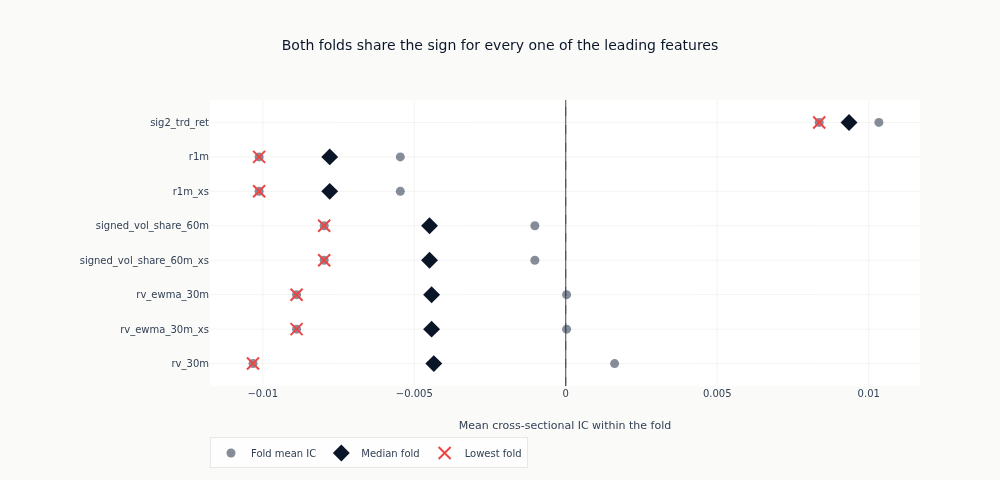

In [18]:
stability_features = [name for name in reversed(leaders) if name in fold_stats]
if stability_features:
    fig = go.Figure()
    _ = fig.add_trace(
        go.Scatter(
            x=[value for name in stability_features for value in fold_stats[name]["fold_ics"]],
            y=[name for name in stability_features for _ in fold_stats[name]["fold_ics"]],
            mode="markers",
            marker={"color": COLORS["neutral"], "size": 9, "opacity": 0.6},
            name="Fold mean IC",
        )
    )
    _ = fig.add_trace(
        go.Scatter(
            x=[fold_stats[name]["median_fold_ic"] for name in stability_features],
            y=stability_features,
            mode="markers",
            marker={"color": COLORS["blue"], "size": 13, "symbol": "diamond"},
            name="Median fold",
        )
    )
    _ = fig.add_trace(
        go.Scatter(
            x=[fold_stats[name]["worst_fold_ic"] for name in stability_features],
            y=stability_features,
            mode="markers",
            marker={
                "color": COLORS["negative"],
                "size": 12,
                "symbol": "x-thin",
                "line": {"width": 2, "color": COLORS["negative"]},
            },
            name="Lowest fold",
        )
    )
    _ = fig.add_vline(x=0, line={"color": COLORS["neutral"], "width": 0.8, "dash": "dash"})
    fig.update_layout(
        title="Both folds share the sign for every one of the leading features",
        xaxis_title="Mean cross-sectional IC within the fold",
        height=480,
        width=1000,
        margin={"l": 210},
        legend={"orientation": "h", "y": -0.18},
    )
    fig.show()

## 3. Search Accounting and Multiple Testing

**The searched set.** A p-value is interpretable only against the set of tests it
came out of, so the set is declared before the adjustment is applied. It is the
union of the financial features `03_financial_features` generates from the window
register at `setup.yaml::features.windows`, in both the level and cross-sectional
z-score representation each family declares, and the model-based features
`04_model_based_features` generates from its estimator families. Generation is
blind to the label: no feature in the set was chosen after seeing an IC, and the
set is the same one whatever this notebook finds. Only the primary label is
screened here; the other declared horizons enter as the sensitivity check below,
not as separate tests.

**The adjustment.** Benjamini-Hochberg at `FDR_ALPHA` over every feature with a
computable cross-sectional IC. Testing each candidate at the same nominal level
would let the expected number of false positives grow in proportion to the size of
the set; BH instead controls the expected share of false discoveries among the
features it rejects. The expected false-positive count under the unadjusted rule
is printed alongside the three significance counts, which is what makes the
adjustment's effect legible.

In [19]:
feature_names = list(ic_results.keys())
p_values = [ic_results[f]["p_value"] for f in feature_names]

fdr_result = benjamini_hochberg_fdr(p_values, alpha=FDR_ALPHA, return_details=True)

# Build evaluation summary
eval_summary = pl.DataFrame(
    {
        "feature": feature_names,
        "source": ["temporal" if f in temporal_cols else "financial" for f in feature_names],
        "ic_mean": [ic_results[f]["mean_ic"] for f in feature_names],
        "hac_se": [ic_results[f]["hac_se"] for f in feature_names],
        "hac_t": [ic_results[f]["t_stat"] for f in feature_names],
        "hac_p": p_values,
        "fdr_p": list(fdr_result["adjusted_p_values"]),
        "fdr_sig": list(fdr_result["rejected"]),
        "naive_t": [ic_results[f]["naive_t_stat"] for f in feature_names],
    },
    schema_overrides={
        "ic_mean": pl.Float64,
        "hac_se": pl.Float64,
        "hac_t": pl.Float64,
        "hac_p": pl.Float64,
        "fdr_p": pl.Float64,
        "fdr_sig": pl.Boolean,
        "naive_t": pl.Float64,
    },
).sort(pl.col("ic_mean").cast(pl.Float64, strict=False).abs(), descending=True)

# The naive tier has to actually be naive. `compute_ic_hac_stats` returns the
# Newey-West p-value and the naive t-statistic; reading the first as if it were the
# unadjusted one makes the inflation ratio a comparison of a quantity with itself.
naive_p_values = [
    float(2 * student_t.sf(abs(ic_results[f]["naive_t_stat"]), df=ic_results[f]["n_periods"] - 1))
    for f in feature_names
]
n_searched = len(feature_names)
expected_false_positives = FDR_ALPHA * n_searched

n_significant_naive = sum(1 for p in naive_p_values if p < FDR_ALPHA)
n_significant_hac = sum(1 for p in p_values if p < FDR_ALPHA)
n_significant_fdr = int(fdr_result["n_rejected"])


def inflation(naive_count: int, adjusted_count: int) -> str:
    """How much the unadjusted count overstates the adjusted one.

    Undefined when the adjustment rejects nothing: substituting one for a zero
    denominator reports a finite ratio where none exists, and the reader cannot
    tell the substitution from a measurement.
    """
    if adjusted_count == 0:
        return "undefined (the adjustment rejected nothing)"
    return f"{naive_count / adjusted_count:.2f}x"


print(f"Searched set: {n_searched} features with a computable IC on {label_col}")
print(f"Expected false positives at the unadjusted level: {expected_false_positives:.1f}")
print(f"Naive significant:            {n_significant_naive}")
print(f"Newey-West significant:       {n_significant_hac}")
print(f"BH-FDR significant:           {n_significant_fdr}")
print(f"Inflation factor (Newey-West): {inflation(n_significant_naive, n_significant_hac)}")
print(f"Inflation factor (BH-FDR):     {inflation(n_significant_naive, n_significant_fdr)}")

Searched set: 81 features with a computable IC on fwd_ret_15m
Expected false positives at the unadjusted level: 4.0
Naive significant:            11
Newey-West significant:       12
BH-FDR significant:           6
Inflation factor (Newey-West): 0.92x
Inflation factor (BH-FDR):     1.83x


### Ranking, with the Inference Adjustment Visible

The left panel ranks the leading features by absolute mean IC and colours each bar
by whether it cleared the false-discovery adjustment, so individual significance
and the set-wide decision stay separable. The right panel plots the Newey-West
t-statistic against its unadjusted twin for every feature in the searched set: a
point pulled toward zero off the diagonal is a feature whose apparent significance
came from serial correlation in the IC series rather than from its size.

Sampling at the label horizon is what leaves the points near the diagonal. It has
already removed the overlap the correction exists to undo, so the two counts of
individually significant features printed above agree, and the reduction in the
candidate set comes from the false-discovery adjustment instead.

Bars run horizontally. At this many feature names a rotated vertical axis is not
legible.

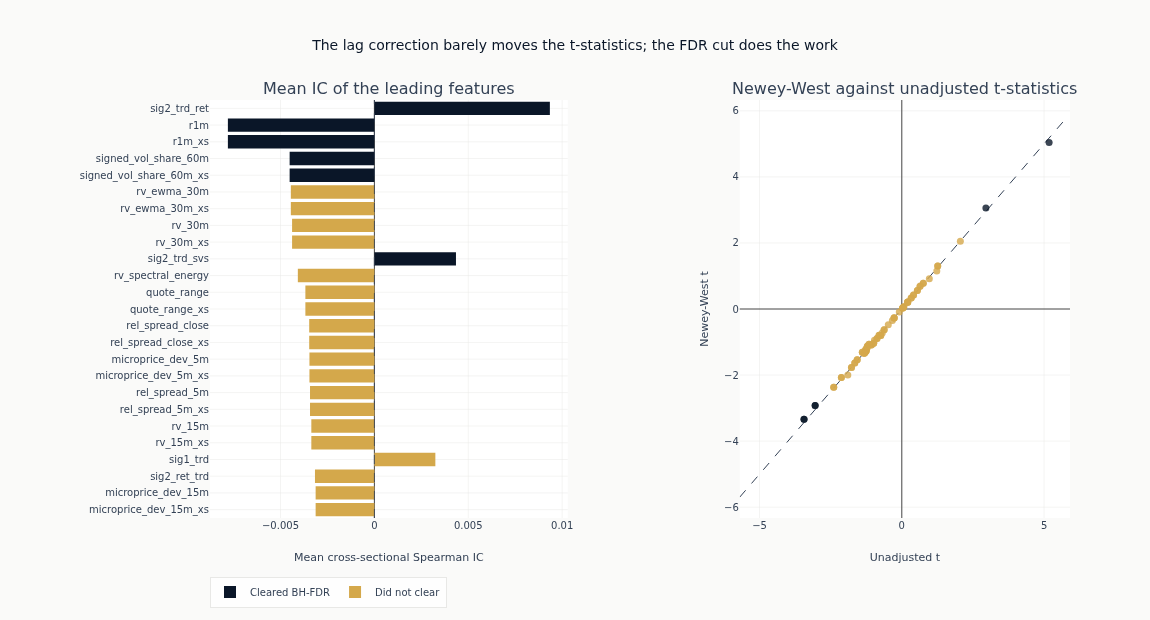

In [20]:
RANKED_FEATURES = 25
top = eval_summary.head(min(RANKED_FEATURES, len(eval_summary))).reverse()

fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.52, 0.48],
    subplot_titles=[
        "Mean IC of the leading features",
        "Newey-West against unadjusted t-statistics",
    ],
    horizontal_spacing=0.2,
)
for cleared, color, name in (
    (True, COLORS["blue"], "Cleared BH-FDR"),
    (False, COLORS["amber"], "Did not clear"),
):
    arm = top.filter(pl.col("fdr_sig").fill_null(False) == cleared)
    if not len(arm):
        continue
    _ = fig.add_trace(
        go.Bar(
            x=arm["ic_mean"].to_list(),
            y=arm["feature"].to_list(),
            orientation="h",
            marker_color=color,
            name=name,
            legendgroup=name,
        ),
        row=1,
        col=1,
    )
_ = fig.add_vline(
    x=0, line={"color": COLORS["neutral"], "width": 0.8, "dash": "dash"}, row=1, col=1
)

max_t = (
    max(
        float(eval_summary["naive_t"].abs().max() or 1.0),
        float(eval_summary["hac_t"].abs().max() or 1.0),
    )
    * 1.1
)
_ = fig.add_trace(
    go.Scatter(
        x=[-max_t, max_t],
        y=[-max_t, max_t],
        mode="lines",
        line={"dash": "dash", "color": COLORS["neutral"], "width": 1},
        name="No adjustment",
        showlegend=False,
    ),
    row=1,
    col=2,
)
for cleared, color, name in (
    (True, COLORS["blue"], "Cleared BH-FDR"),
    (False, COLORS["amber"], "Did not clear"),
):
    arm = eval_summary.filter(pl.col("fdr_sig").fill_null(False) == cleared)
    if not len(arm):
        continue
    _ = fig.add_trace(
        go.Scatter(
            x=arm["naive_t"].to_list(),
            y=arm["hac_t"].to_list(),
            mode="markers",
            marker={"color": color, "size": 7, "opacity": 0.8},
            text=arm["feature"].to_list(),
            name=name,
            legendgroup=name,
            showlegend=False,
        ),
        row=1,
        col=2,
    )

fig.update_layout(
    title="The lag correction barely moves the t-statistics; the FDR cut does the work",
    height=620,
    width=1150,
    margin={"l": 210},
    legend={"orientation": "h", "y": -0.14},
)
# Two traces split the ranking by outcome, so the y order has to be restated or the
# categories fall in trace order and the ranking the panel exists to show is lost.
fig.update_yaxes(categoryorder="array", categoryarray=top["feature"].to_list(), row=1, col=1)
fig.update_xaxes(title_text="Mean cross-sectional Spearman IC", row=1, col=1)
fig.update_xaxes(title_text="Unadjusted t", row=1, col=2)
fig.update_yaxes(title_text="Newey-West t", row=1, col=2)
fig.show()

### The Same Features Against the Other Declared Horizons

The screen above reads one label. The case study ships three continuous forward
returns, and a feature whose association is confined to the shortest of them cannot
be held for the length of the others. Each horizon gets its own seal, because a
longer forward return settles later: a row eligible under the primary label can
still have its 60-minute label realized inside the evaluation window.

**Caveat.** The sampling step is one primary horizon, so at the longer horizons
consecutive observations of the IC series do overlap. That inflates the effective
sample of the longer horizons relative to the shortest one; the ratio in the right
panel is the more affected of the two, and the ordering across horizons is what to
read, not the level.

In [21]:
horizon_rows = []
for variant_label, variant_minutes in LABEL_HORIZONS.items():
    variant_seal = (pl.col(DATE_COL) + pl.duration(minutes=variant_minutes)) < HOLDOUT_START
    variant = (
        pl.scan_parquet(CASE_DIR / "labels" / f"{variant_label}.parquet")
        .filter(variant_seal)
        .select([*JOIN_COLS, variant_label])
        .collect()
    )
    frame = eval_sampled.select([*JOIN_COLS, *leaders]).join(variant, on=JOIN_COLS, how="inner")
    horizon_ic_wide = (
        frame.group_by(DATE_COL)
        .agg([pl.corr(f, variant_label, method="spearman").alias(f) for f in leaders])
        .sort(DATE_COL)
    )
    for feature in leaders:
        series = horizon_ic_wide.filter(pl.col(feature).is_finite())[feature]
        dispersion = float(series.std()) if len(series) > 1 else float("nan")
        horizon_rows.append(
            {
                "feature": feature,
                "horizon": variant_minutes,
                "ic_mean": float(series.mean()),
                "icir": float(series.mean()) / dispersion if dispersion else float("nan"),
            }
        )
    del variant, frame, horizon_ic_wide

horizon_ic = pl.DataFrame(horizon_rows)
print(f"Horizon profile computed for {len(horizon_rows)} feature-horizon pairs")

Horizon profile computed for 24 feature-horizon pairs


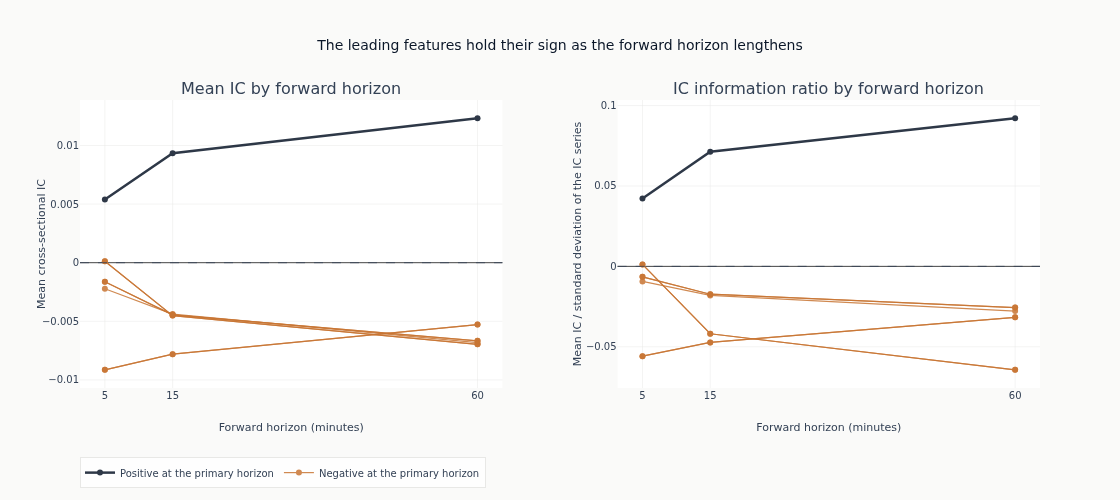

In [22]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "Mean IC by forward horizon",
        "IC information ratio by forward horizon",
    ),
    horizontal_spacing=0.12,
)
shown_direction = set()
for feature in leaders:
    profile = horizon_ic.filter(pl.col("feature") == feature).sort("horizon")
    if not len(profile):
        continue
    positive = float(profile.filter(pl.col("horizon") == LABEL_HORIZON)["ic_mean"][0]) > 0
    group = "Positive at the primary horizon" if positive else "Negative at the primary horizon"
    style = {
        "color": COLORS["blue"] if positive else COLORS["copper"],
        "width": 2.5 if feature == leader else 1.2,
    }
    for column, column_index in (("ic_mean", 1), ("icir", 2)):
        first = column_index == 1 and group not in shown_direction
        _ = fig.add_trace(
            go.Scatter(
                x=profile["horizon"],
                y=profile[column],
                mode="lines+markers",
                line=style,
                opacity=0.85,
                name=group,
                legendgroup=group,
                showlegend=first,
                hovertext=feature,
            ),
            row=1,
            col=column_index,
        )
    shown_direction.add(group)
_ = fig.add_hline(y=0, line={"color": COLORS["neutral"], "width": 0.8, "dash": "dash"})
fig.update_layout(
    title="The leading features hold their sign as the forward horizon lengthens",
    height=500,
    width=1120,
    legend={"orientation": "h", "y": -0.24},
)
for column_index in (1, 2):
    fig.update_xaxes(
        title_text="Forward horizon (minutes)",
        tickmode="array",
        tickvals=sorted(LABEL_HORIZONS.values()),
        row=1,
        col=column_index,
    )
fig.update_yaxes(title_text="Mean cross-sectional IC", row=1, col=1)
fig.update_yaxes(title_text="Mean IC / standard deviation of the IC series", row=1, col=2)
fig.show()

## 4. Shape Diagnostics

Quantile monotonicity: does the mean forward return spread monotonically across
feature quintiles? A monotone relationship is compatible with the ranking-based
mapping the strategy applies; a high IC with a flat or U-shaped profile is not, and
is usually outlier-driven correlation.

**How the bins are assigned, and what that costs.** The bin edges below come from
the pooled sealed sample rather than from within each decision time, so a bar
mixes cross-sectional position with time-series level and every other timestamp's
distribution helps set this timestamp's edges. Book §7.3 specifies the within-date
construction, which is what the companion IC already uses. The divergence moves
the `monotonicity` column of the ledger and is tracked in the stage-05 notebook
standard rather than changed here.
Read the profiles below as pooled shape, not as a within-date sort. The clearest
reading of what that costs is a feature and its own cross-sectional z-score twin:
ranking within a date leaves the two identical, so their cross-sectional ICs are
equal to every digit, and any difference in their quantile profiles here is the
pooled binning speaking rather than the features.

In [23]:
N_QUANTILES = 5
top_features_for_shape = eval_summary.filter(pl.col("fdr_sig").fill_null(False))[
    "feature"
].to_list()[:15]

if not top_features_for_shape:
    # Fallback: top 10 by absolute IC
    top_features_for_shape = eval_summary.head(10)["feature"].to_list()

monotonicity_scores = {}
quantile_spreads = {}
for feat in top_features_for_shape:
    valid = eval_panel.select([feat, label_col]).drop_nulls()
    if len(valid) < N_QUANTILES * 20:
        continue
    valid = valid.with_columns(
        pl.col(feat)
        .qcut(N_QUANTILES, labels=[f"Q{i + 1}" for i in range(N_QUANTILES)])
        .alias("quantile")
    )
    q_means = valid.group_by("quantile").agg(pl.col(label_col).mean()).sort("quantile")
    means = q_means[label_col].to_list()
    spread = means[-1] - means[0]
    quantile_spreads[feat] = {"q_means": means, "spread": spread}

    mono_corr, _ = spearmanr(range(len(means)), means)  # imported at top
    monotonicity_scores[feat] = float(mono_corr)

n_monotone = sum(1 for s in monotonicity_scores.values() if abs(s) >= MONOTONICITY_MIN)
print(
    f"Quantile analysis: {n_monotone}/{len(monotonicity_scores)} features with"
    f" |monotonicity| >= {MONOTONICITY_MIN}"
)

Quantile analysis: 6/6 features with |monotonicity| >= 0.8


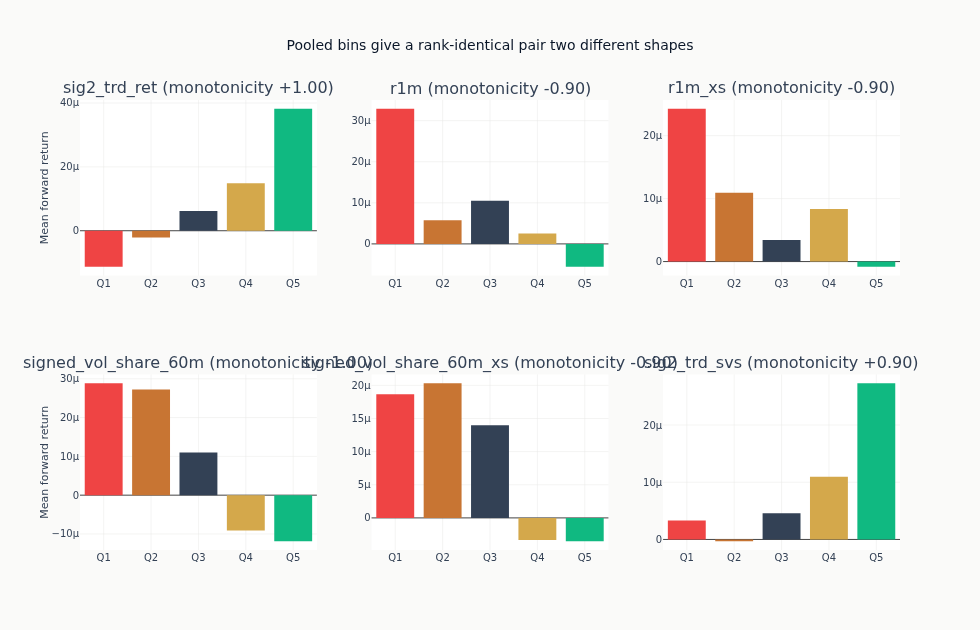

In [24]:
QUANTILE_SHADES = [
    COLORS["negative"],
    COLORS["copper"],
    COLORS["neutral"],
    COLORS["amber"],
    COLORS["positive"],
]
if quantile_spreads:
    n_show = min(6, len(quantile_spreads))
    feats_to_show = list(quantile_spreads.keys())[:n_show]
    ncols = min(3, n_show)
    nrows = (n_show + ncols - 1) // ncols
    fig = make_subplots(
        rows=nrows,
        cols=ncols,
        subplot_titles=[
            f"{feat} (monotonicity {monotonicity_scores[feat]:+.2f})" for feat in feats_to_show
        ],
        vertical_spacing=0.22,
    )
    for idx, feat in enumerate(feats_to_show):
        r, c = divmod(idx, ncols)
        q_means = quantile_spreads[feat]["q_means"]
        _ = fig.add_trace(
            go.Bar(
                x=[f"Q{i + 1}" for i in range(len(q_means))],
                y=q_means,
                marker_color=QUANTILE_SHADES[: len(q_means)],
                showlegend=False,
            ),
            row=r + 1,
            col=c + 1,
        )
    fig.update_layout(
        title="Pooled bins give a rank-identical pair two different shapes",
        height=270 * nrows + 90,
        width=980,
    )
    fig.update_yaxes(title_text="Mean forward return", col=1)
    fig.show()

## 5. Redundancy & Feature Families

Identify highly correlated feature pairs and aggregate IC by family. Correlated
features carry redundant information, and the modeling stage has to pick one of
each pair rather than let a regularized fit split their weight between the two.

**Where the families come from.** The financial families are the ones
`setup.yaml::features.families` declares, matched by the `pattern` each family
carries. Reading them from the declaration rather than retyping a lookup table
keeps one definition of what a family is, and it is what puts a feature and its
cross-sectional z-score twin in the same family: the declaration says each family
is represented at both scales, so `rel_spread_15m` and `rel_spread_15m_xs` are the
same hypothesis measured twice, not two hypotheses. The model-based families are
not declared in `setup.yaml` — they are the estimator families
`04_model_based_features` builds — so they are assigned from the column names it
writes.

In [25]:
# The declared patterns are globs over column names; `*` is any suffix, which is how
# a family claims both the level and its `_xs` twin.
DECLARED_FAMILIES = [
    (family["name"], re.compile("^(?:" + family["pattern"].replace("*", ".*") + ")$"))
    for family in setup["features"]["families"]
]


def declared_family(feat: str) -> str | None:
    """The `setup.yaml` family whose pattern claims this column, if any."""
    base = feat[: -len("_xs")] if feat.endswith("_xs") else feat
    for name, pattern in DECLARED_FAMILIES:
        if pattern.match(feat) or pattern.match(base):
            return name
    return None


def model_based_family(feat: str) -> str:
    """Estimator family, from the column names `04_model_based_features` writes."""
    lowered = feat.lower()
    if "har" in lowered:
        return "temporal_har"
    if any(k in lowered for k in ("spectral", "fft", "freq", "period", "entropy")):
        return "temporal_fft"
    if "sig" in lowered:
        return "temporal_signature"
    return "temporal_other"


families = {}
for feat in all_feature_cols:
    declared = declared_family(feat)
    if declared is not None:
        families[feat] = declared
    elif feat in temporal_cols:
        families[feat] = model_based_family(feat)
    else:
        families[feat] = "other"

unclaimed = sorted(f for f, fam in families.items() if fam == "other")
if unclaimed:
    print(f"Features matched by no declared family: {unclaimed}")

In [26]:
# Pairwise correlation (sample timestamps for efficiency)
sample_corr_step = max(1, n_dates // 200)
corr_dates = eval_panel[DATE_COL].unique().sort().to_list()[::sample_corr_step]
corr_data = eval_panel.filter(pl.col(DATE_COL).is_in(corr_dates)).select(evaluable_features)
corr_matrix = corr_data.to_pandas().corr(method="spearman")

# Count high-correlation pairs
high_corr_pairs = []
for i in range(len(corr_matrix)):
    for j in range(i + 1, len(corr_matrix)):
        if abs(corr_matrix.iloc[i, j]) > REDUNDANCY_CUT:
            high_corr_pairs.append(
                (corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])
            )

print(f"Redundancy cut: |rank correlation| > {REDUNDANCY_CUT}")
print(f"Feature pairs above the cut: {len(high_corr_pairs)}")

Redundancy cut: |rank correlation| > 0.7
Feature pairs above the cut: 80


In [27]:
# Family-level IC summary
family_ic = {}
fdr_sig_features = eval_summary.filter(pl.col("fdr_sig").fill_null(False))["feature"].to_list()

for feat in ic_results:
    fam = families.get(feat, "other")
    family_ic.setdefault(fam, []).append(
        {
            "feature": feat,
            "ic": ic_results[feat]["mean_ic"],
            "fdr_sig": feat in fdr_sig_features,
        }
    )

family_summary = {}
for fam, feats in sorted(family_ic.items()):
    ics = [f["ic"] for f in feats if f["ic"] is not None]
    n_sig = sum(1 for f in feats if f["fdr_sig"])
    family_summary[fam] = {
        "n_features": len(feats),
        "avg_abs_ic": float(np.mean([abs(ic) for ic in ics])) if ics else 0.0,
        "avg_ic": float(np.mean(ics)) if ics else 0.0,
        "n_fdr_sig": n_sig,
    }

if family_summary:
    fam_df = pl.DataFrame([{"family": fam, **stats} for fam, stats in family_summary.items()]).sort(
        "avg_abs_ic", descending=True
    )
    print(fam_df)
else:
    fam_df = pl.DataFrame()
    print("No features passed IC evaluation threshold")

shape: (9, 5)
┌────────────────────┬────────────┬────────────┬───────────┬───────────┐
│ family             ┆ n_features ┆ avg_abs_ic ┆ avg_ic    ┆ n_fdr_sig │
│ ---                ┆ ---        ┆ ---        ┆ ---       ┆ ---       │
│ str                ┆ i64        ┆ f64        ┆ f64       ┆ i64       │
╞════════════════════╪════════════╪════════════╪═══════════╪═══════════╡
│ volatility         ┆ 15         ┆ 0.003753   ┆ -0.00362  ┆ 2         │
│ microprice         ┆ 6          ┆ 0.002733   ┆ -0.002733 ┆ 0         │
│ quote_liquidity    ┆ 12         ┆ 0.002583   ┆ -0.002122 ┆ 0         │
│ price_impact       ┆ 8          ┆ 0.002395   ┆ -0.000917 ┆ 0         │
│ temporal_signature ┆ 12         ┆ 0.002149   ┆ 0.001091  ┆ 2         │
│ temporal_har       ┆ 2          ┆ 0.001449   ┆ 0.000464  ┆ 0         │
│ order_flow         ┆ 21         ┆ 0.001433   ┆ -0.001032 ┆ 2         │
│ hidden_liquidity   ┆ 2          ┆ 0.000728   ┆ 0.000728  ┆ 0         │
│ temporal_fft       ┆ 3          ┆ 0

### The Strongest Redundant Pairs

Ranked pairs rather than the full matrix. At this many features an unmasked
heatmap is mostly empty space with tick labels too small to read, and the question
the section asks is about specific pairs: which two candidates are the same
evidence entered twice. Each bar names both members and the family each belongs
to, so a pair drawn from one family and a pair spanning two are distinguishable —
the second kind is the one a family-by-family selection would miss. The counts
printed below the figure separate the two, and separate out the pairs that are a
level against its own cross-sectional z-score, which are redundant by
construction rather than by anything the data did.

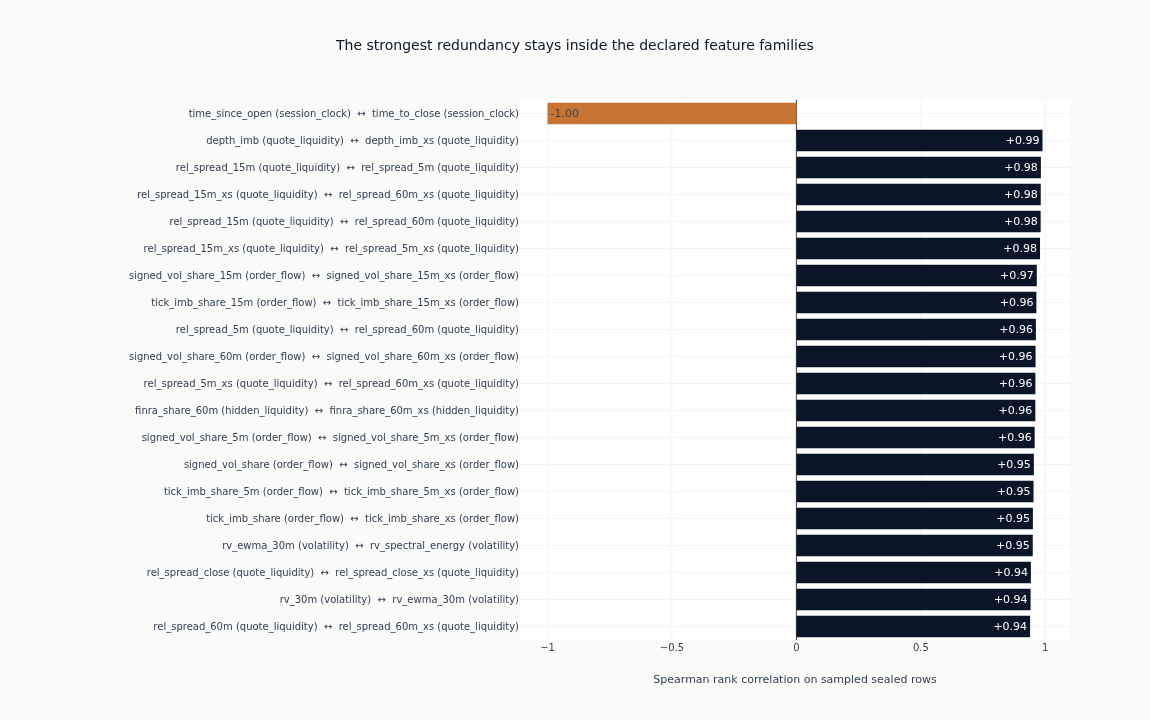

Of the 20 strongest pairs, 0 span two families
Of the 20 strongest pairs, 11 are a level against its own z-score


In [28]:
RANKED_PAIRS = 20
if high_corr_pairs:
    ranked = sorted(high_corr_pairs, key=lambda pair: abs(pair[2]), reverse=True)[:RANKED_PAIRS]
    pair_labels = [
        f"{left} ({families.get(left, 'other')})  ↔  {right} ({families.get(right, 'other')})"
        for left, right, _ in ranked
    ]
    pair_values = [float(value) for _, _, value in ranked]
    cross_family = sum(
        families.get(left, "other") != families.get(right, "other") for left, right, _ in ranked
    )
    # A level against its own cross-sectional z-score: the same measurement twice,
    # which the family declaration already says is one hypothesis on two scales.
    same_twin = sum(left == f"{right}_xs" or right == f"{left}_xs" for left, right, _ in ranked)
    fig = go.Figure(
        go.Bar(
            x=list(reversed(pair_values)),
            y=list(reversed(pair_labels)),
            orientation="h",
            marker_color=[
                COLORS["blue"] if value > 0 else COLORS["copper"] for value in reversed(pair_values)
            ],
            text=[f"{value:+.2f}" for value in reversed(pair_values)],
            textposition="inside",
        )
    )
    fig.update_layout(
        title="The strongest redundancy stays inside the declared feature families",
        xaxis_title="Spearman rank correlation on sampled sealed rows",
        height=720,
        width=1150,
        margin={"l": 520},
        showlegend=False,
    )
    fig.show()
    print(f"Of the {len(ranked)} strongest pairs, {cross_family} span two families")
    print(f"Of the {len(ranked)} strongest pairs, {same_twin} are a level against its own z-score")

## 6. Triage & Handoff

The book's Table 7.2 rule, with every bound taken from the configuration cell. The
promotion rule is a **disjunction**, so a feature reaches PROCEED on either arm and
the promoted count can exceed the count that cleared the adjustment. Which arm
fired is recorded in the ledger's `note` column, so the decision can be audited
rather than inferred.

| Decision | Criteria |
|----------|----------|
| **PROCEED** | cleared BH-FDR, **or** sign consistency at least `SIGN_CONSISTENCY_MIN` and absolute mean IC at least `IC_THRESHOLD` |
| **STOP** | failed the correctness screen: coverage below `COVERAGE_MIN`, or staleness above `STALENESS_MAX` |
| **REVISE** | everything else — carried forward to be judged in a multivariate fit |

`monotonicity` is written to the ledger as evidence and is **not** read by the rule
above. A reader comparing the promoted count to the FDR count should not expect the
shape diagnostic to explain the gap.

In [29]:
triage = {}
for feat in all_feature_cols:
    if not correctness[feat]:
        triage[feat] = ("STOP", "correctness_fail")
        continue

    if feat not in ic_results:
        triage[feat] = ("REVISE", "insufficient_data")
        continue

    is_fdr_sig = feat in fdr_sig_features
    sign_con = fold_stats.get(feat, {}).get("sign_consistency", 0)
    abs_ic = abs(ic_results[feat]["mean_ic"])

    if is_fdr_sig:
        triage[feat] = ("PROCEED", "fdr_significant")
    elif sign_con >= SIGN_CONSISTENCY_MIN and abs_ic >= IC_THRESHOLD:
        triage[feat] = ("PROCEED", "stable_and_above_threshold")
    else:
        triage[feat] = ("REVISE", "not_significant_standalone")

In [30]:
# Build triage ledger
ledger_rows = []
for feat in all_feature_cols:
    decision, note = triage[feat]
    row = {
        "feature": feat,
        "family": families.get(feat, "other"),
        "source": "temporal" if feat in temporal_cols else "financial",
        "ic_mean": ic_results.get(feat, {}).get("mean_ic"),
        "hac_t": ic_results.get(feat, {}).get("t_stat"),
        "hac_p": ic_results.get(feat, {}).get("p_value"),
        "fdr_p": None,
        "fdr_sig": False,
        "sign_consistency": fold_stats.get(feat, {}).get("sign_consistency"),
        "worst_fold_ic": fold_stats.get(feat, {}).get("worst_fold_ic"),
        "monotonicity": monotonicity_scores.get(feat),
        "coverage": coverage[feat],
        "staleness": staleness[feat],
        "decision": decision,
        "note": note,
    }
    match = eval_summary.filter(pl.col("feature") == feat)
    if len(match) > 0:
        row["fdr_p"] = float(match["fdr_p"][0])
        row["fdr_sig"] = bool(match["fdr_sig"][0])
    ledger_rows.append(row)

triage_ledger = pl.DataFrame(ledger_rows)

# Save triage ledger
triage_ledger.write_parquet(EVAL_WRITE_DIR / "triage_ledger.parquet")
print(f"\nTriage ledger: {EVAL_DIR / 'triage_ledger.parquet'}")
print(triage_ledger.group_by("decision").len().sort("decision"))


Triage ledger: ~/ml4t/public-cs05-foldfix/case_studies/nasdaq100_microstructure/evaluation/triage_ledger.parquet
shape: (3, 2)
┌──────────┬─────┐
│ decision ┆ len │
│ ---      ┆ --- │
│ str      ┆ u32 │
╞══════════╪═════╡
│ PROCEED  ┆ 7   │
│ REVISE   ┆ 76  │
│ STOP     ┆ 5   │
└──────────┴─────┘


In [31]:
# Save IC time series (long format)
ic_ts_frames = []
for feat, ts in ic_timeseries.items():
    ic_ts_frames.append(ts.with_columns(pl.lit(feat).alias("feature")))

if ic_ts_frames:
    ic_ts_all = pl.concat(ic_ts_frames)
    ic_ts_all.write_parquet(EVAL_WRITE_DIR / "ic_timeseries.parquet")
    print(f"IC time series: {EVAL_DIR / 'ic_timeseries.parquet'}")

IC time series: ~/ml4t/public-cs05-foldfix/case_studies/nasdaq100_microstructure/evaluation/ic_timeseries.parquet


In [32]:
proceed_features = [f for f, (d, _) in triage.items() if d == "PROCEED"]
revise_features = [f for f, (d, _) in triage.items() if d == "REVISE"]
stop_features = [f for f, (d, _) in triage.items() if d == "STOP"]

print(f"TRIAGE SUMMARY: {CASE_STUDY_ID}")
print(f"  PROCEED: {len(proceed_features)} features")
print(f"  REVISE:  {len(revise_features)} features")
print(f"  STOP:    {len(stop_features)} features")
print(triage_ledger.group_by("note").len().sort("len", descending=True))

TRIAGE SUMMARY: nasdaq100_microstructure
  PROCEED: 7 features
  REVISE:  76 features
  STOP:    5 features
shape: (5, 2)
┌────────────────────────────┬─────┐
│ note                       ┆ len │
│ ---                        ┆ --- │
│ str                        ┆ u32 │
╞════════════════════════════╪═════╡
│ not_significant_standalone ┆ 74  │
│ fdr_significant            ┆ 6   │
│ correctness_fail           ┆ 5   │
│ insufficient_data          ┆ 2   │
│ stable_and_above_threshold ┆ 1   │
└────────────────────────────┴─────┘


### The Funnel

What was searched, what survived each stage, and what each arm of the promotion
rule contributed. Drawn rather than printed, because the width of the drop between
consecutive bars is what a reader is meant to weigh, and the two arms are separated
so a rule that reads as a disjunction can be seen to behave like one — or not.

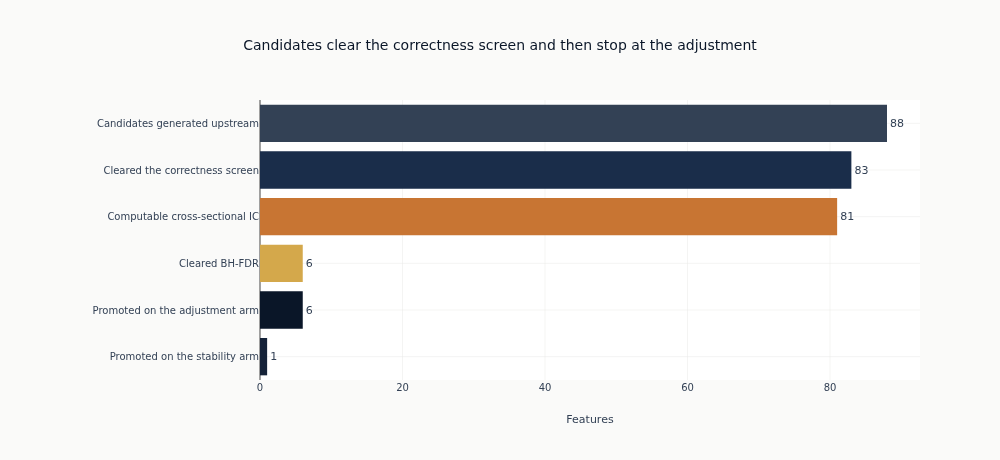

Promoted by arm: {'fdr_significant': 6, 'stable_and_above_threshold': 1}


In [33]:
arm_counts = {
    note: len([f for f, (d, n) in triage.items() if d == "PROCEED" and n == note])
    for note in ("fdr_significant", "stable_and_above_threshold")
}
funnel_stages = [
    ("Candidates generated upstream", len(all_feature_cols), COLORS["neutral"]),
    ("Cleared the correctness screen", n_pass, COLORS["slate"]),
    ("Computable cross-sectional IC", n_searched, COLORS["copper"]),
    ("Cleared BH-FDR", n_significant_fdr, COLORS["amber"]),
    ("Promoted on the adjustment arm", arm_counts["fdr_significant"], COLORS["blue"]),
    (
        "Promoted on the stability arm",
        arm_counts["stable_and_above_threshold"],
        COLORS["blue_light"],
    ),
]
fig = go.Figure(
    go.Bar(
        x=[count for _, count, _ in funnel_stages],
        y=[stage for stage, _, _ in funnel_stages],
        orientation="h",
        marker_color=[color for _, _, color in funnel_stages],
        text=[str(count) for _, count, _ in funnel_stages],
        textposition="outside",
    )
)
fig.update_layout(
    title="Candidates clear the correctness screen and then stop at the adjustment",
    xaxis_title="Features",
    height=460,
    width=1000,
    margin={"l": 260, "r": 80},
    showlegend=False,
)
fig.update_yaxes(autorange="reversed")
fig.show()
print(f"Promoted by arm: {arm_counts}")

## Key Takeaways

### What the screen does

1. **Seal first.** The panel is narrowed on the label endpoint before any statistic
   is computed, so the coverage screen, the IC, the quantile profile and the
   redundancy correlation all describe development data only. A disclosure in prose
   is not a seal; a filter and an assertion are.
2. **One cross-sectional IC per decision time**, sampled at one observation per
   label horizon so consecutive observations do not share their forward window,
   then averaged with a Newey-West correction over one session of lags.
3. **Declare the searched set before the p-value.** The adjustment is only
   interpretable against the set of tests it came out of, and that set is fixed by
   the upstream generation rules rather than by what this notebook found.
4. **Correctness screens** catch coverage gaps and stale features before they
   contaminate the IC.

### Triage logic

- **PROCEED**: statistical evidence of predictive content on either arm of the
  disjunction. Carried into model training.
- **REVISE**: marginal standalone, may still contribute in a multivariate fit,
  which is where regularization and importance judge it.
- **STOP**: failed a basic quality check.

### Known limitations of this screen

- Sign consistency counts folds with a positive IC rather than folds sharing the
  feature's own direction, so a stably negative feature cannot clear the stability
  arm.
- Quantile bins are assigned over the pooled sealed sample rather than within each
  decision time, which is a different question from the one the IC answers.
- The minimum cross-section is applied to panel rows, not to non-null
  feature-label pairs, so a sparse feature can contribute a thin cross-section at
  full weight.
- Univariate triage is necessary and not sufficient. Nothing here claims
  tradability; the multivariate fit and the backtest decide that.

**Next**: `20_strategy_synthesis/02_feature_evaluation.py` reads
`evaluation/triage_ledger.parquet` from every case study and puts the nine screens
side by side. `evaluation/ic_timeseries.parquet` is read here, by the
IC-through-time figure above.